In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

target = 'selling_price'

X_train_df = train_df.drop(columns=[target])
X_test_df = test_df.drop(columns=[target])

X_train = X_train_df.values
y_train = train_df[target].values

X_test = X_test_df.values
y_test = test_df[target].values

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_sklearn = rf_model.predict(X_test)

sklearn_mae = mean_absolute_error(y_test, y_pred_sklearn)
sklearn_mse = mean_squared_error(y_test, y_pred_sklearn)
sklearn_rmse = np.sqrt(sklearn_mse)

print(f"MAE:  {sklearn_mae:.2f}")
print(f"MSE:  {sklearn_mse:.2f}")
print(f"RMSE: {sklearn_rmse:.2f}")

=== SKLEARN RANDOM FOREST FULL RESULTS ===
MAE:  57462.25
MSE:  7151438126.01
RMSE: 84566.18


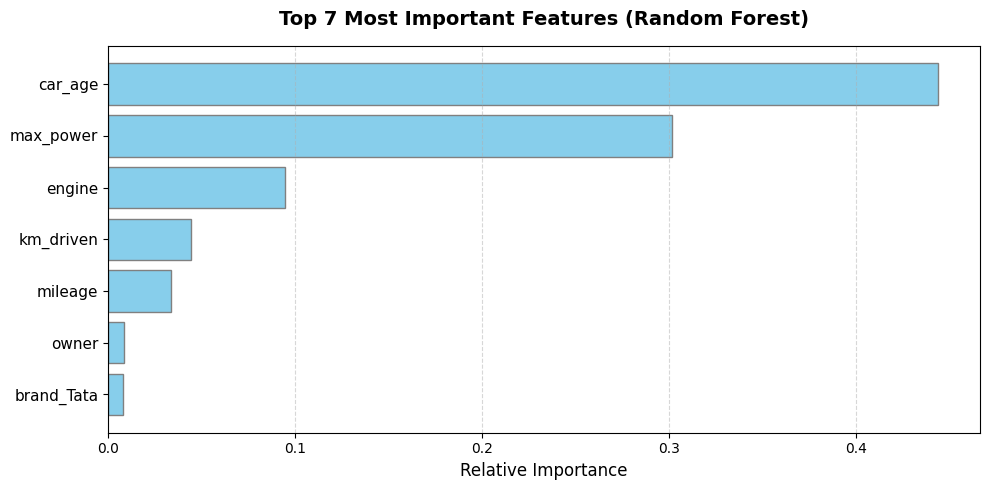

In [26]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.feature_importances_
features = X_train_df.columns

indices = np.argsort(importances)

top_n = 7
top_indices = indices[-top_n:]

plt.figure(figsize=(10, 5))
plt.title("Top 7 Most Important Features (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.barh(range(top_n), importances[top_indices], color='skyblue', align='center', edgecolor='grey')
plt.yticks(range(top_n), [features[i] for i in top_indices], fontsize=11)
plt.xlabel("Relative Importance", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()